# Netflix Content Analysis: Genres, Release Years, and Catalog Trends

**Student Name:** Sam Sikder  
**Course:** IS 362  
**Final Project**

---

In [2]:
import pandas as pd

df = pd.read_csv("netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
# Basic information about dataset

print("Rows and Columns:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

Rows and Columns:
(8807, 12)

Column Names:
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

Missing Values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [4]:
# Clean and convert date_added column safely

df["date_added"] = df["date_added"].str.strip()

df["date_added"] = pd.to_datetime(
    df["date_added"],
    errors="coerce",
    format="mixed"
)

print(df["date_added"].head())
print(df.dtypes)

0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[ns]
show_id                 object
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
description             object
dtype: object


In [5]:
# Count Movies vs TV Shows

print(df["type"].value_counts())

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


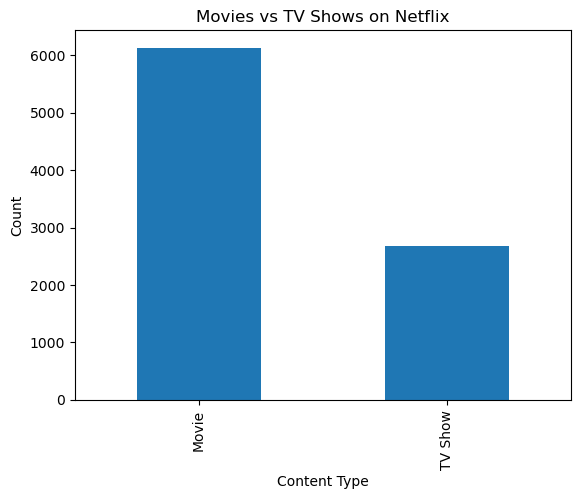

In [6]:
import matplotlib.pyplot as plt

df["type"].value_counts().plot(kind="bar")

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Count")

plt.show()

In [7]:
genres = (
    df["listed_in"]
    .str.split(", ")
    .explode()
)

top_genres = genres.value_counts().head(10)

print(top_genres)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


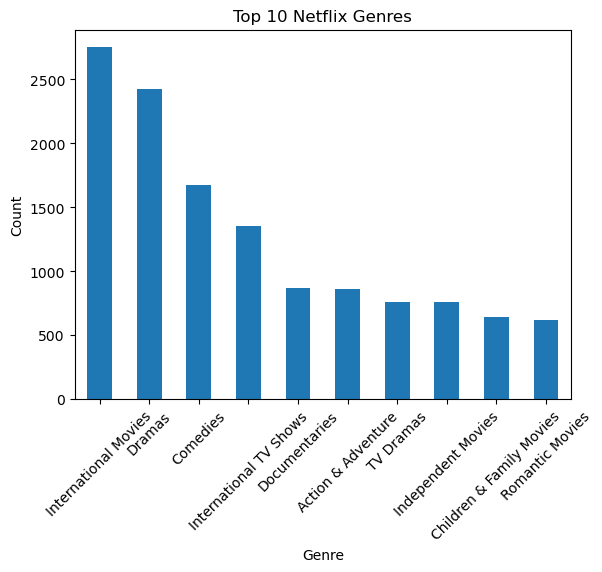

In [8]:
top_genres.plot(kind="bar")

plt.title("Top 10 Netflix Genres")
plt.xlabel("Genre")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [9]:
import sqlite3

conn = sqlite3.connect("netflix.db")

df.to_sql(
    "netflix_titles",
    conn,
    if_exists="replace",
    index=False
)

print("Database created successfully")

Database created successfully


In [10]:
query = """
SELECT type, COUNT(*) as total
FROM netflix_titles
GROUP BY type
"""

sql_results = pd.read_sql(query, conn)

print(sql_results)

      type  total
0    Movie   6131
1  TV Show   2676


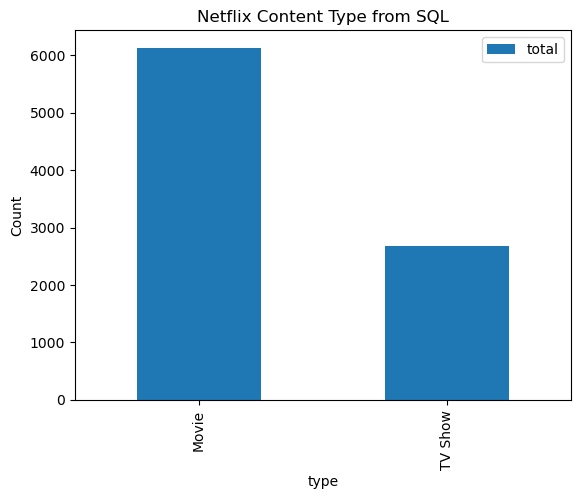

In [11]:
sql_results.plot(
    x="type",
    y="total",
    kind="bar"
)

plt.title("Netflix Content Type from SQL")
plt.ylabel("Count")

plt.show()

In [12]:
# Average release year by content type

avg_year = df.groupby("type")["release_year"].mean()

print(avg_year)

type
Movie      2013.121514
TV Show    2016.605755
Name: release_year, dtype: float64


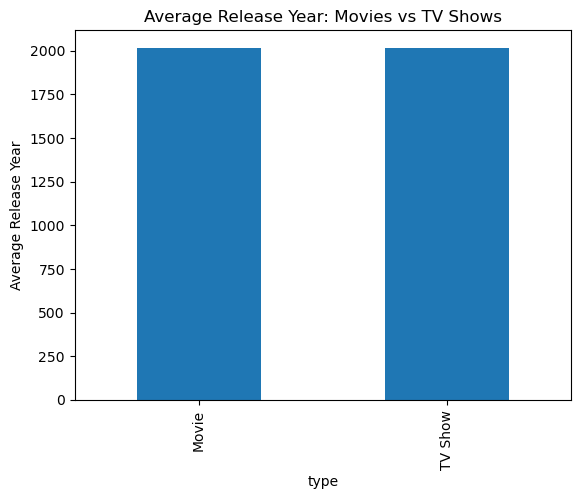

In [13]:
avg_year.plot(kind="bar")

plt.title("Average Release Year: Movies vs TV Shows")
plt.ylabel("Average Release Year")

plt.show()

# Netflix Content Analysis

## Objective
The purpose of this project is to analyze Netflix content data to identify patterns in genres, release years, ratings, and catalog trends.

## Data Sources
- Netflix Movies and TV Shows dataset from Kaggle
- SQLite relational database created from the dataset

## Data Cleaning
The dataset was cleaned by converting date fields and handling missing values.

## Findings
- International Movies were the most common genre.
- Movies significantly outnumbered TV Shows.

## Challenges Encountered

During the project I encountered several challenges. Initially, the Netflix CSV dataset was not uploaded correctly, which caused file loading errors in Jupyter Notebook. I also experienced issues converting the `date_added` column into datetime format because some values had formatting inconsistencies. These issues were resolved by properly uploading the dataset and using safer datetime conversion methods.

## Statistical Analysis

The average release year for Movies was approximately 2013, while the average release year for TV Shows was approximately 2017. This suggests that TV Shows on Netflix tend to be newer and may reflect Netflix's increasing focus on serialized content.

## Conclusions

The analysis showed that Movies significantly outnumber TV Shows on Netflix. International Movies and Dramas were the most common genres in the dataset. Results also indicated that Netflix has increasingly invested in newer TV content over time.

In [16]:
import requests
import pandas as pd

url = "https://api.tvmaze.com/search/shows?q=netflix"

response = requests.get(url)

api_data = response.json()

api_df = pd.json_normalize(api_data)

api_df.head()

,score,show.id,show.url,show.name,show.type,show.language,show.genres,show.status,show.runtime,show.averageRuntime,...,show._links.self.href,show._links.previousepisode.href,show._links.previousepisode.name,show.network.id,show.network.name,show.network.country.name,show.network.country.code,show.network.country.timezone,show.network.officialSite,show.webChannel
0,0.594399,51875,https://www.tvmaze.com/shows/51875/the-netflix...,The Netflix Afterparty,Talk Show,English,[Comedy],Ended,NaN,36,...,https://api.tvmaze.com/shows/51875,https://api.tvmaze.com/episodes/2085341,The Upshaws,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.588090,61403,https://www.tvmaze.com/shows/61403/barbie-netf...,Barbie Netflix Movies,Animation,English,[Children],Ended,NaN,61,...,https://api.tvmaze.com/shows/61403,https://api.tvmaze.com/episodes/2506024,Barbie: Skipper and the Big Babysitting Adventure,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.539008,12567,https://www.tvmaze.com/shows/12567/netflix-pre...,Netflix Presents: The Characters,Variety,English,[Comedy],Ended,NaN,33,...,https://api.tvmaze.com/shows/12567,https://api.tvmaze.com/episodes/636384,Dr. Brown,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.511705,72028,https://www.tvmaze.com/shows/72028/octonauts-n...,Octonauts Netflix Movies,Animation,English,[],Ended,NaN,64,...,https://api.tvmaze.com/shows/72028,https://api.tvmaze.com/episodes/2667953,Octonauts & The Ring of Fire,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.460840,87596,https://www.tvmaze.com/shows/87596/spongebob-s...,SpongeBob SquarePants Netflix Movies,Animation,English,[],Running,NaN,88,...,https://api.tvmaze.com/shows/87596,https://api.tvmaze.com/episodes/3395525,Plankton: The Movie,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Additional Data Source (API)

A TVMaze API request was used to collect supplementary show-related information. This demonstrates the use of a second data source type beyond the Netflix CSV dataset and expands the project's data collection workflow.

- Multiple source types were used, including a CSV dataset and a web API.
- TV Shows had a newer average release year than Movies.
- International Movies and Dramas dominated the Netflix catalog.

In [19]:
# Rank top genres

genre_ranking = top_genres.rank(
    ascending=False,
    method="dense"
)

print(genre_ranking)

listed_in
International Movies         1.0
Dramas                       2.0
Comedies                     3.0
International TV Shows       4.0
Documentaries                5.0
Action & Adventure           6.0
TV Dramas                    7.0
Independent Movies           8.0
Children & Family Movies     9.0
Romantic Movies             10.0
Name: count, dtype: float64
